   # Are you in danger of being affected by Corona Virus?

![](https://api.time.com/wp-content/uploads/2020/04/CoronavirusFAQOpener.jpg?quality=85&w=1024&h=512&crop=1)
<br>
## What is Covid-19 Virus?
Coronavirus disease (COVID-19) is an infectious disease caused by a newly discovered coronavirus.
<br>
Most people infected with the COVID-19 virus will experience mild to moderate respiratory illness and recover without requiring special treatment.  Older people, and those with underlying medical problems like cardiovascular disease, diabetes, chronic respiratory disease, and cancer are more likely to develop serious illness.
<br>
![](https://encrypted-tbn0.gstatic.com/images?q=tbn%3AANd9GcT52W_CHOK4IlkWHeqoKGRQExWxMKD4fEPmeg&usqp=CAU)
<br>
The best way to prevent and slow down transmission is to be well informed about the COVID-19 virus, the disease it causes and how it spreads. Protect yourself and others from infection by washing your hands or using an alcohol based rub frequently and not touching your face. 
<br><br>
The COVID-19 virusspreads primarily through droplets of saliva or discharge from the nose when an infected person coughs or sneezes, so it’s important that you also practice respiratory etiquette (for example, by coughing into a flexed elbow).



## Note:
The data obtained is from the Mexican government and hence, the analysis is valid for Mexico or maybe North America. The pandemic stats and behaviours are extremely different for Asian countries when compared to North American or European countries owing to far lower case fatality rate for Asia.

## Data Dictionary:
<ol>
    <li>id: The identification number of the patient</li>.
    <li>sex: Identify gender of the patient, 1 as female and 2 as male.</li>
    <li>patient_type: Type of patient, 1 for not hospitalized and 2 for hosptalized.</li>
    <li>entry_date: The date that the patient went to the hospital.</li>
    <li>date_symptoms: The date that the patient started to show symptoms.</li>
    <li>date_died: The date that the patient died, “9999-99-99” stands for recovered.</li>
    <li>intubed: Intubation is a procedure that’s used when you can’t breathe on your own. Your doctor puts a tube down your throat and into your windpipe to make it easier to get air into and out of your lungs. A machine called a ventilator pumps in air with extra oxygen. Then it helps you breathe out air that’s full of carbon dioxide (CO2). “1” denotes that the patient used ventilator and “2” denotes that the patient did not, “97” “98” “99” means not specified.</li>
    <li>pneumonia: Indicates whether the patient already have air sacs inflammation or not “1” for yes, “2” for no, “97” “98” “99” means not specified.</li>
    <li>age: Specifies the age of the patient.</li>
    <li>pregnancy: Indicates whether the patient is pregnant or not, “1” for yes, “2” for no, “97” “98” “99” means not specified.</li>
    <li>diabetes: Indicates whether the patient has diabetes or not, “1” for yes, “2” for no, “97” “98” “99” means not specified.</li>
    <li>copd: Indicates whether the patient has Chronic obstructive pulmonary disease (COPD) or not, “1” for yes, “2” for no, “97” “98” “99” means not specified.</li>
    <li>asthma: Indiactes whether the patient has asthma or not, “1” for yes, “2” for no, “97” “98” “99” means not specified.</li>
    <li>inmsupr: Indicates whether the patient is immunosuppressed or not, “1” for yes, “2” for no, “97” “98” “99” means not specified.</li>
    <li>hypertension: Indicates whether the patient has hypertension or not, “1” for yes, “2” for no, “97” “98” “99” means not specified.</li>
    <li>other_disease: Indicates whether the patient has other disease or not, “1” for yes, “2” for no, “97” “98” “99” means not specified.</li>
    <li>cardiovascular: Indicates whether if the patient has heart or blood vessels realted disease, “1” for yes, “2” for no, “97” “98” “99” means not specified.</li>
    <li>obesity: Indicates whether the patient is obese or not, “1” for yes, “2” for no, “97” “98” “99” means not specified.</li>
    <li>renal_chronic: Indicates whether the patient has chronic renal disease or not, “1” for yes, “2” for no, “97” “98” “99” means not specified.</li>
    <li>tobacco: Indicates whether if the patient is a tobacco user, “1” for yes, “2” for no, “97” “98” “99” means not specified.</li>
    <li>contact_other_covid: Indicates whether if the patient has contacted another covid19 patient.</li>
    <li>icu: Indicates whether the if the patient had been admitted to an Intensive Care Unit (ICU), “1” for yes, “2” for no, “97” “98” “99” means not specified.</li>
    <li>covid_res: 1 indicates person is covid +ve,2 indicates person is covide -ve,3 indicates result is in awaiting process</li>  
</ol>







































In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/covid19-patient-precondition-dataset/covid.csv
/kaggle/input/covid19-patient-precondition-dataset/Description.xlsx
/kaggle/input/covid19-patient-precondition-dataset/Catalogs.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
df=pd.read_csv('../input/covid19-patient-precondition-dataset/covid.csv')

In [4]:
df.head()

,id,sex,patient_type,entry_date,date_symptoms,date_died,intubed,pneumonia,age,pregnancy,...,inmsupr,hypertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,contact_other_covid,covid_res,icu
0,16169f,2,1,04-05-2020,02-05-2020,9999-99-99,97,2,27,97,...,2,2,2,2,2,2,2,2,1,97
1,1009bf,2,1,19-03-2020,17-03-2020,9999-99-99,97,2,24,97,...,2,2,2,2,2,2,2,99,1,97
2,167386,1,2,06-04-2020,01-04-2020,9999-99-99,2,2,54,2,...,2,2,2,2,1,2,2,99,1,2
3,0b5948,2,2,17-04-2020,10-04-2020,9999-99-99,2,1,30,97,...,2,2,2,2,2,2,2,99,1,2
4,0d01b5,1,2,13-04-2020,13-04-2020,22-04-2020,2,2,60,2,...,2,1,2,1,2,2,2,99,1,2


In [5]:
df.describe()

,sex,patient_type,intubed,pneumonia,age,pregnancy,diabetes,copd,asthma,inmsupr,hypertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,contact_other_covid,covid_res,icu
count,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000
mean,1.506726,1.215165,76.562952,1.846262,42.622483,50.400692,2.210633,2.280221,2.265029,2.319628,2.145774,2.410030,2.286157,2.138905,2.283765,2.238360,31.573034,1.728651,76.562864
std,0.499955,0.410937,39.058676,0.560939,16.659973,47.501579,5.683523,5.327832,5.334658,5.667381,5.459866,6.489959,5.438405,5.395578,5.393232,5.571901,45.082123,0.658710,39.059060
min,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,97.000000,2.000000,31.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,97.000000
50%,2.000000,1.000000,97.000000,2.000000,41.000000,97.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,97.000000
75%,2.000000,1.000000,97.000000,2.000000,53.000000,97.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,99.000000,2.000000,97.000000
max,2.000000,2.000000,99.000000,99.000000,120.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,99.000000,3.000000,99.000000


In [6]:
df.shape

(566602, 23)

In [7]:
df.isnull().sum()

id                     0
sex                    0
patient_type           0
entry_date             0
date_symptoms          0
date_died              0
intubed                0
pneumonia              0
age                    0
pregnancy              0
diabetes               0
copd                   0
asthma                 0
inmsupr                0
hypertension           0
other_disease          0
cardiovascular         0
obesity                0
renal_chronic          0
tobacco                0
contact_other_covid    0
covid_res              0
icu                    0
dtype: int64

In [8]:
df.drop(columns={'entry_date','date_died','date_symptoms','id'},axis=1,inplace=True)
df.shape

(566602, 19)

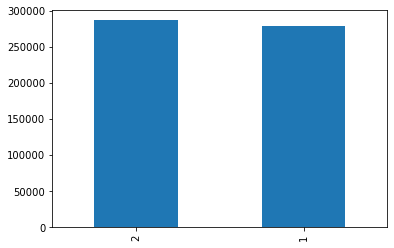

In [9]:

df["sex"].value_counts().plot.bar()

In [10]:
df['covid_res'].value_counts().to_frame()

,covid_res
2,279035
1,220657
3,66910


****TEST RESULT****<br>
<ol>
    <li>positive</li>
    <li>negative</li>
    <li>awaitinga</li>
</ol>

Now here,we are replacing 1 with 1,2 with 0 and 3 with 2

In [11]:
df['covid_res'].replace([1,2,3],[1,0,2],inplace=True)
df['covid_res'].value_counts().to_frame()

,covid_res
0,279035
1,220657
2,66910


Text(0.5, 1.0, 'Covid Result')

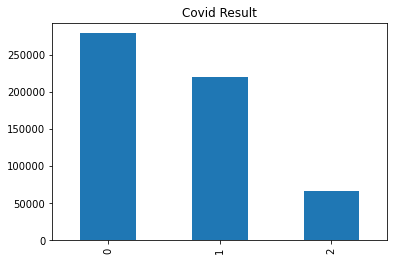

In [12]:
df['covid_res'].value_counts().sort_index().plot.bar()
plt.title('Covid Result')

<ol>
    <li>0-negative</li>
    <li>1-positive</li>
    <li>2-awaiting</li>
</ol>

In [13]:
df.rename(columns={'covid_res':'Chance'},inplace=True)
df.head()

,sex,patient_type,intubed,pneumonia,age,pregnancy,diabetes,copd,asthma,inmsupr,hypertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,contact_other_covid,Chance,icu
0,2,1,97,2,27,97,2,2,2,2,2,2,2,2,2,2,2,1,97
1,2,1,97,2,24,97,2,2,2,2,2,2,2,2,2,2,99,1,97
2,1,2,2,2,54,2,2,2,2,2,2,2,2,1,2,2,99,1,2
3,2,2,2,1,30,97,2,2,2,2,2,2,2,2,2,2,99,1,2
4,1,2,2,2,60,2,1,2,2,2,1,2,1,2,2,2,99,1,2


**Since we are focusing on giving the chances of being affected by corona,so our main focus will be on either chance is positive or negative, hence we'll neglect awaiting chances..<br>
Now here i am dropping all those rows which contains chance is  awaiting i.e.2 value**

In [14]:
df=df[df['Chance']!=2]

Text(0.5, 1.0, 'Chance')

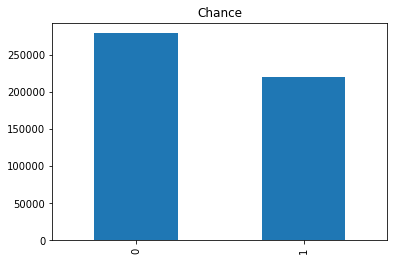

In [15]:
df['Chance'].value_counts().sort_index().plot.bar()
plt.title('Chance')

In [16]:
lst=df.columns
for i in range(19):
    print(df[lst[i]].value_counts().to_frame())
    print("----------------")

      sex
2  253098
1  246594
----------------
   patient_type
1        392146
2        107546
----------------
    intubed
97   392146
2     98321
1      9103
99      122
----------------
    pneumonia
2      420965
1       78716
99         11
----------------
       age
30   12872
31   12298
36   12292
38   12259
37   12248
..     ...
115      1
111      1
107      1
118      1
105      1

[120 rows x 1 columns]
----------------
    pregnancy
97     253098
2      241644
1        3614
98       1336
----------------
    diabetes
2     435702
1      62349
98      1641
----------------
      copd
2   489970
1     8276
98    1446
----------------
    asthma
2   482036
1    16214
98    1442
----------------
    inmsupr
2    489959
1      8071
98     1662
----------------
    hypertension
2         416863
1          81340
98          1489
----------------
    other_disease
2          482107
1           15392
98           2193
----------------
    cardiovascular
2           486764
1         

# NOTE:- 
As we are focusing on prediction of chances of being affected by corona virus,so here I'm dropping all those values which indicates NaN values<br>
All those values except 1 and 2 are NaN 

**INTUBED**

Text(0.5, 1.0, 'Intubed')

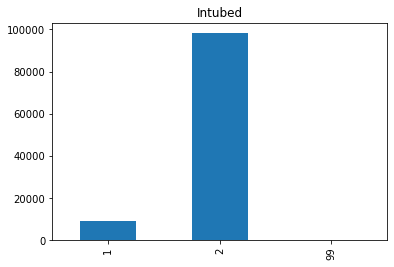

In [17]:
df=df[df['intubed']!=97]
df['intubed'].value_counts().sort_index().plot.bar()
plt.title('Intubed')

In [18]:
df=df[df['intubed']!=99]
df['intubed'].value_counts().to_frame()

,intubed
2,98321
1,9103


**PNEUMONIA**

Text(0.5, 1.0, 'pneumonia')

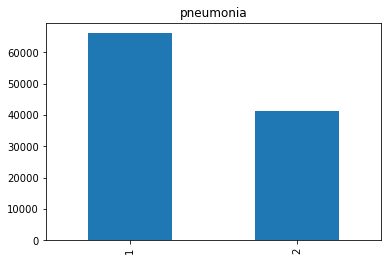

In [19]:
df=df[df['pneumonia']!=99]
df['pneumonia'].value_counts().sort_index().plot.bar()
plt.title('pneumonia')


**Pregnancy**

Text(0.5, 1.0, 'Pregnancy')

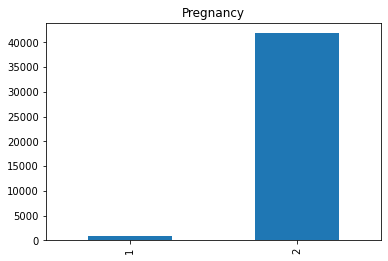

In [20]:
df=df[df['pregnancy']!=97]
df=df[df['pregnancy']!=98]
df['pregnancy'].value_counts().sort_index().plot.bar()
plt.title('Pregnancy')

**Diabetes**

Text(0.5, 1.0, 'Diabetes')

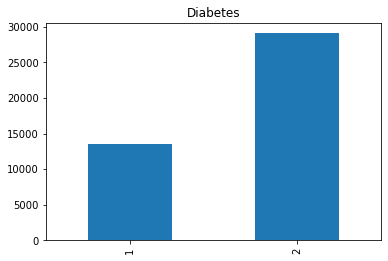

In [21]:
df=df[df['diabetes']!=98]
df['diabetes'].value_counts().sort_index().plot.bar()
plt.title('Diabetes')

**C.O.P.D.**

Text(0.5, 1.0, 'COPD')

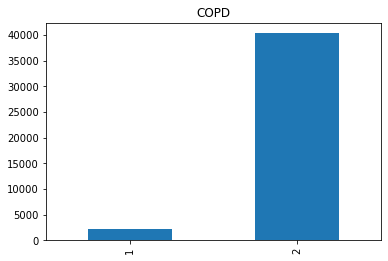

In [22]:
df=df[df['copd']!=98]
df['copd'].value_counts().sort_index().plot.bar()
plt.title('COPD')

**ASTHMA**

Text(0.5, 1.0, 'Asthma')

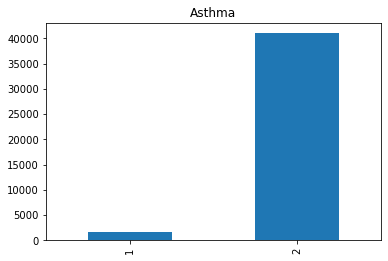

In [23]:
df=df[df['asthma']!=98]
df['asthma'].value_counts().sort_index().plot.bar()
plt.title('Asthma')

**Inmsupr**

Text(0.5, 1.0, 'Inmsupr')

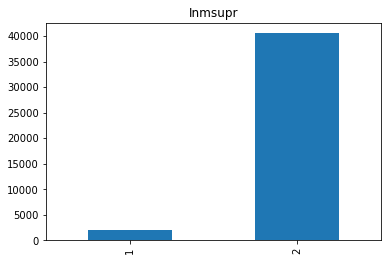

In [24]:
df=df[df['inmsupr']!=98]
df['inmsupr'].value_counts().sort_index().plot.bar()
plt.title('Inmsupr')

**Hypertension**

Text(0.5, 1.0, 'Hypertension')

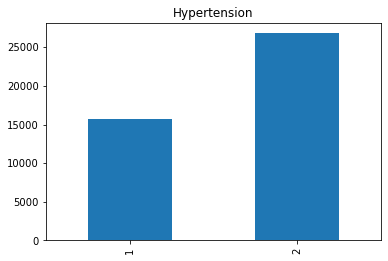

In [25]:
df=df[df['hypertension']!=98]
df['hypertension'].value_counts().sort_index().plot.bar()
plt.title('Hypertension')

**OTHER_DISEASE**

Text(0.5, 1.0, 'Other Disease')

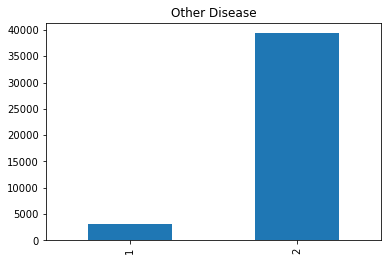

In [26]:
df=df[df['other_disease']!=98]
df['other_disease'].value_counts().sort_index().plot.bar()
plt.title('Other Disease')

**Cardiovascular**

Text(0.5, 1.0, 'Cardiovascular')

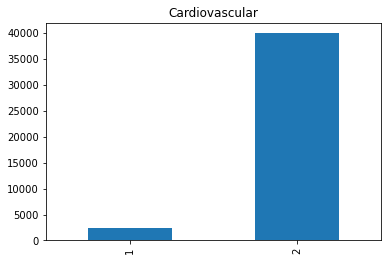

In [27]:
df=df[df['cardiovascular']!=98]
df['cardiovascular'].value_counts().sort_index().plot.bar()
plt.title('Cardiovascular')

**Obesity**

Text(0.5, 1.0, 'Obesity')

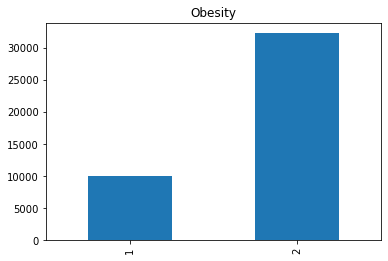

In [28]:
df=df[df['obesity']!=98]
df['obesity'].value_counts().sort_index().plot.bar()
plt.title('Obesity')

**Renal Chronic**

Text(0.5, 1.0, 'Renal Chronic')

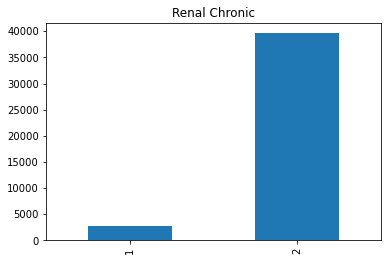

In [29]:
df=df[df['renal_chronic']!=98]
df['renal_chronic'].value_counts().sort_index().plot.bar()
plt.title('Renal Chronic')

**Tobacco**

2    40303
1     1988
Name: tobacco, dtype: int64


Text(0.5, 1.0, 'Tobacco')

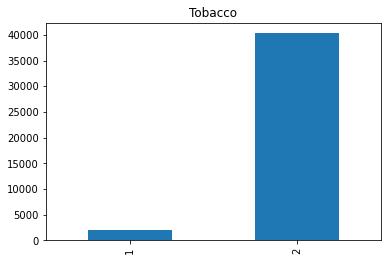

In [30]:
df=df[df['tobacco']!=98]
print(df['tobacco'].value_counts())
df['tobacco'].value_counts().sort_index().plot.bar()
plt.title('Tobacco')

**Contact with Covid Person**

Text(0.5, 1.0, 'Contact other covid')

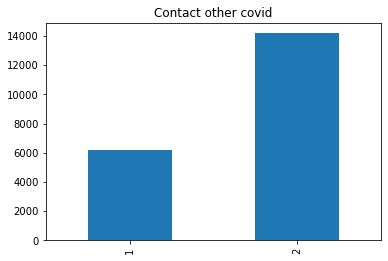

In [31]:
df=df[df['contact_other_covid']!=99]
df['contact_other_covid'].value_counts().sort_index().plot.bar()
plt.title('Contact other covid')

**ICU**

Text(0.5, 1.0, 'ICU')

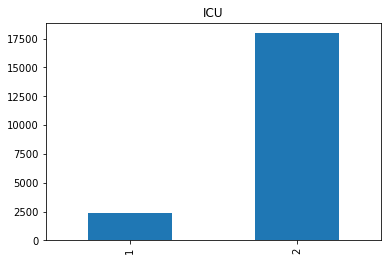

In [32]:
df=df[df['icu']!=99]
df=df[df['icu']!=97]

df['icu'].value_counts().sort_index().plot.bar()
plt.title('ICU')

**As we have removed unwanted rows, now we'll reset index**

In [33]:
df.reset_index(drop=True,inplace=True)
df.head(10)

,sex,patient_type,intubed,pneumonia,age,pregnancy,diabetes,copd,asthma,inmsupr,hypertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,contact_other_covid,Chance,icu
0,1,2,2,2,25,2,2,2,2,2,2,2,2,2,2,2,1,1,2
1,1,2,2,2,52,2,2,2,2,2,2,2,2,1,2,1,1,1,2
2,1,2,2,1,51,2,2,2,2,2,2,2,2,2,2,2,1,1,2
3,1,2,1,1,67,2,1,2,2,2,1,2,2,1,2,2,1,1,2
4,1,2,2,1,59,2,1,2,2,2,2,2,2,2,2,2,1,1,2
5,1,2,2,2,52,2,1,2,2,2,1,2,1,2,2,2,2,1,2
6,1,2,2,1,54,2,2,2,2,2,2,2,2,2,2,2,2,1,2
7,1,2,2,1,78,2,2,2,2,2,1,2,2,1,2,2,1,1,1
8,1,2,2,1,80,2,1,2,2,2,1,2,2,1,2,2,1,1,2
9,1,2,2,2,40,2,2,2,2,2,2,2,2,2,2,2,2,1,2


**Data Visualization**

Text(0.5, 1.0, 'Correlation heatmap')

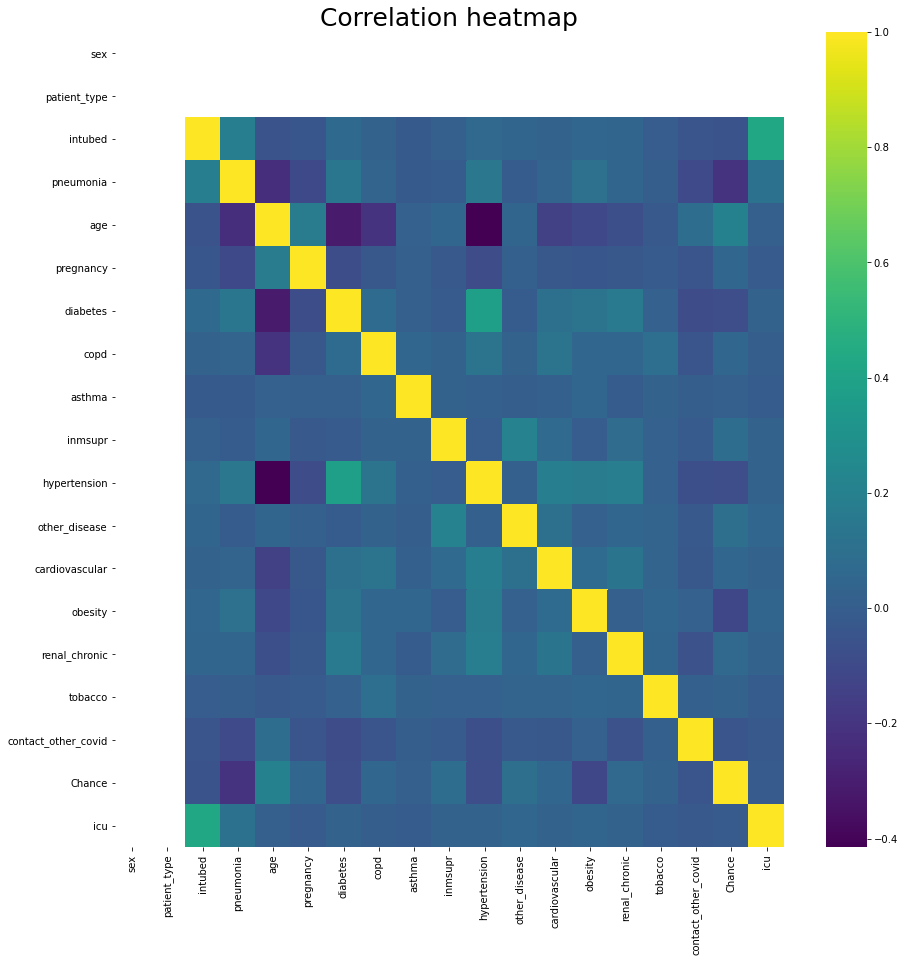

In [34]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(),cmap='viridis')
plt.title('Correlation heatmap',size=25)

Text(13.06111979166667, 0.5, 'Count')

<Figure size 504x360 with 0 Axes>

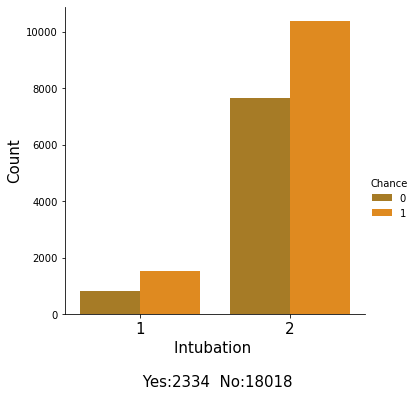

In [35]:
plt.figure(figsize=(7,5))
sns.catplot('intubed',data=df,kind='count',palette='autumn_d',hue='Chance')
plt.xticks(size=15,)
plt.xlabel('Intubation \n \n Yes:{}  No:{}'.format(df['intubed'].value_counts()[1] , df['intubed'].value_counts()[2]),size=15)
plt.ylabel('Count',size=15)

In [36]:
features=['sex', 'patient_type', 'intubed', 'pneumonia', 'age', 'pregnancy',
       'diabetes', 'copd', 'asthma', 'inmsupr', 'hypertension',
       'other_disease', 'cardiovascular', 'obesity', 'renal_chronic',
       'tobacco', 'contact_other_covid', 'icu']
list(enumerate(features))

[(0, 'sex'),
 (1, 'patient_type'),
 (2, 'intubed'),
 (3, 'pneumonia'),
 (4, 'age'),
 (5, 'pregnancy'),
 (6, 'diabetes'),
 (7, 'copd'),
 (8, 'asthma'),
 (9, 'inmsupr'),
 (10, 'hypertension'),
 (11, 'other_disease'),
 (12, 'cardiovascular'),
 (13, 'obesity'),
 (14, 'renal_chronic'),
 (15, 'tobacco'),
 (16, 'contact_other_covid'),
 (17, 'icu')]

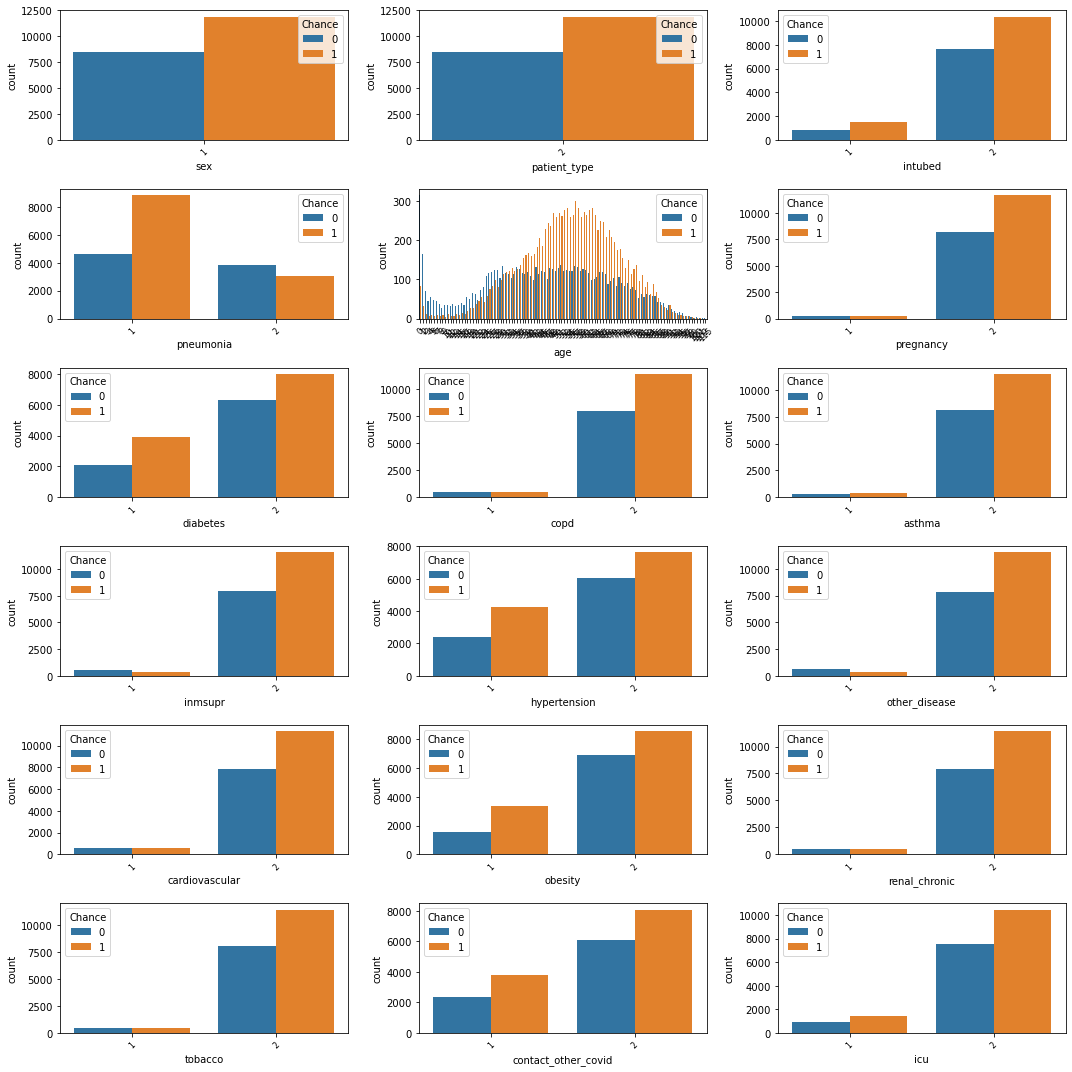

In [37]:
plt.figure(figsize=(15,15))
for i in enumerate(features):
    plt.subplot(6,3,i[0]+1)
    sns.countplot(i[1],hue='Chance',data=df)
    plt.xticks(rotation=45,size=8)
    plt.tight_layout()               
                  

**Splitting the data into train and test**

In [38]:
train=df[['sex', 'patient_type', 'intubed', 'pneumonia', 'age', 'pregnancy',
       'diabetes', 'copd', 'asthma', 'inmsupr', 'hypertension',
       'other_disease', 'cardiovascular', 'obesity', 'renal_chronic',
       'tobacco', 'contact_other_covid', 'icu']]

In [39]:
test=df['Chance']
train=train.values
test=np.array(test)

**Splitting further into 8:2 ratio**

In [40]:
x_train,x_test,y_train,y_test=train_test_split(train,test,test_size=0.2,random_state=42,stratify=test)
print("Size of X_train is:{}\nSize of Y_train is:{}\nSize of X_test is:{}\nSize of Y_test is:{}\n".format(x_train.shape,
                                      y_train.shape,
                                      x_test.shape,
                                      y_test.shape
                                      ))

Size of X_train is:(16281, 18)
Size of Y_train is:(16281,)
Size of X_test is:(4071, 18)
Size of Y_test is:(4071,)



In [41]:
acc=[]

# Training the model using different algorithms

**KNN**

In [42]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

for i in range(1,25):
    
    neigh=KNeighborsClassifier(n_neighbors = i).fit(x_train,y_train)
    yhat = neigh.predict(x_test)
    KNN_score=metrics.accuracy_score(y_test, yhat)
    print("Train set Accuracy at {} is {}  ".format(i,metrics.accuracy_score(y_train, neigh.predict(x_train))))
    print("Test set Accuracy at {} is {}".format(i,KNN_score))
    print("\n")

Train set Accuracy at 1 is 0.7602727105214667  
Test set Accuracy at 1 is 0.5843773028739867


Train set Accuracy at 2 is 0.6857686874270622  
Test set Accuracy at 2 is 0.5436010808155245


Train set Accuracy at 3 is 0.7184448129721761  
Test set Accuracy at 3 is 0.6086956521739131


Train set Accuracy at 4 is 0.6944290891222897  
Test set Accuracy at 4 is 0.5880619012527635


Train set Accuracy at 5 is 0.7052392359191696  
Test set Accuracy at 5 is 0.6209776467698355


Train set Accuracy at 6 is 0.6967016768011793  
Test set Accuracy at 6 is 0.6192581675264063


Train set Accuracy at 7 is 0.6997727412321111  
Test set Accuracy at 7 is 0.6261360845001228


Train set Accuracy at 8 is 0.6960260426263744  
Test set Accuracy at 8 is 0.6212232866617539


Train set Accuracy at 9 is 0.6961488852036116  
Test set Accuracy at 9 is 0.6369442397445345


Train set Accuracy at 10 is 0.6951661445857135  
Test set Accuracy at 10 is 0.6352247605011054


Train set Accuracy at 11 is 0.6935691910816288  

**Note:** at n_neighbours=11 we are getting max train and test accuracy i.e, 64% and 62% respectively.

In [43]:
acc.append(0.6290)

**Decision Tree**

In [44]:
for i in range(1,25):
    drugTree = DecisionTreeClassifier(criterion="entropy", max_depth = i)
    drugTree.fit(x_train,y_train)
    predTree = drugTree.predict(x_test)
    decisionTree_score=metrics.accuracy_score(y_test, predTree)
    print("DecisionTrees's Accuracy at {} is {}\n".format(i,metrics.accuracy_score(y_test, predTree)))

DecisionTrees's Accuracy at 1 is 0.6408744780152297

DecisionTrees's Accuracy at 2 is 0.6408744780152297

DecisionTrees's Accuracy at 3 is 0.6443134365020879

DecisionTrees's Accuracy at 4 is 0.6475067550970277

DecisionTrees's Accuracy at 5 is 0.6575779906656841

DecisionTrees's Accuracy at 6 is 0.6548759518545811

DecisionTrees's Accuracy at 7 is 0.653647752394989

DecisionTrees's Accuracy at 8 is 0.6590518300171948

DecisionTrees's Accuracy at 9 is 0.6568410709899287

DecisionTrees's Accuracy at 10 is 0.658069270449521

DecisionTrees's Accuracy at 11 is 0.6494718742323753

DecisionTrees's Accuracy at 12 is 0.6502087939081307

DecisionTrees's Accuracy at 13 is 0.6435765168263325

DecisionTrees's Accuracy at 14 is 0.6428395971505773

DecisionTrees's Accuracy at 15 is 0.6455416359616801

DecisionTrees's Accuracy at 16 is 0.6389093588798821

DecisionTrees's Accuracy at 17 is 0.6330140014738393

DecisionTrees's Accuracy at 18 is 0.6261360845001228

DecisionTrees's Accuracy at 19 is 0.621

**Note:** we are getting max test accuracy at max_depth=4 i.e., 64%.

In [45]:
acc.append(0.6401)

**Logistic Regression**

In [46]:
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression(C=0.03, solver='liblinear')
LR.fit(x_train,y_train)
yhat = LR.predict(x_test)
yhat_prob = LR.predict_proba(x_test)
logReg_score=metrics.accuracy_score(y_test, yhat)
print("LogisticRegression's Accuracy:{0}".format(metrics.accuracy_score(y_test, yhat)))

LogisticRegression's Accuracy:0.6590518300171948


In [47]:
acc.append(logReg_score)

**SVM**

In [48]:
from sklearn import svm
clf = svm.SVC(kernel='rbf')
clf.fit(x_train, y_train) 
yhat = clf.predict(x_test)
svm_score=metrics.accuracy_score(y_test, yhat)
print("SVM's Accuracy:{0}".format(metrics.accuracy_score(y_test, yhat)))

SVM's Accuracy:0.6452959960697617


In [49]:
acc.append(svm_score)

**Random Forest Classifier**

In [50]:
from sklearn.ensemble import RandomForestClassifier
Random_forest = RandomForestClassifier(n_estimators=50)
Random_forest.fit(x_train,y_train)
randomForest_predict = Random_forest.predict(x_test)
randomForest_score = metrics.accuracy_score(y_test, randomForest_predict)
print("Random Forest Score :",randomForest_score)

Random Forest Score : 0.6266273642839597


In [51]:
acc.append(randomForest_score)

**Gradient Boosting**

In [52]:
from sklearn.ensemble import GradientBoostingClassifier

gbk = GradientBoostingClassifier(random_state=100, n_estimators=150,min_samples_split=100, max_depth=6)
gbk.fit(x_train, y_train)
gbk_predict = gbk.predict(x_test)
gbk_score = gbk.score(x_test,y_test)
#print("Gradient Boosting Prediction :",gbk_predict)
print("Gradient Boosting Score :",gbk_score)

Gradient Boosting Score : 0.660280029476787


In [53]:
acc.append(gbk_score)
algo_name=['KNN','Decision Tree','Logistic Regression','SVM','Random Forest','Gradient Boosting']
acc=np.array(acc)

## Conclusion

Text(0, 0.5, 'Algorithm Name')

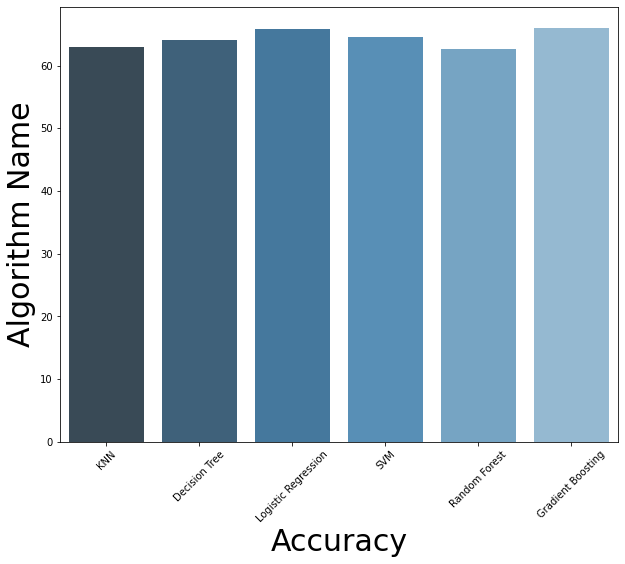

In [54]:
from numpy import median
plt.figure(figsize=(10,8))
sns.barplot(y=acc*100,x=algo_name,estimator=median,palette="Blues_d")
plt.xlabel('Accuracy',size=30)
plt.xticks(rotation=45)
plt.ylabel('Algorithm Name',size=30)

**From different algo used, it is pretty clear that nearly 64% prediction is accurate for being known whether you are in danger or not from being affected by covid-19.**

# Please Upvote if you found my notebook helpful!!



## Say NO to Corona !
## Stay Safe.

**THANK YOU!**
